En este experimento se evalúa el rendimiento de distintos modelos de anotación celular utilizando el framework **DANCE** sobre el dataset **Mouse Cell Atlas (MCA)**. DANCE proporciona un conjunto de herramientas integral para facilitar el desarrollo de algoritmos de análisis de células individuales y la comparación justa del rendimiento en diferentes conjuntos de datos de referencia.




# **Configuración del entorno**

La configuración del entorno se integra directamente en el notebook. Con el objetivo de mejorar la trazabilidad, se opta por **clonar el repositorio oficial de DANCE e instalarlo en modo editable**. Asimismo, se fijan versiones concretas de las librerías principales.

## **Configuración inicial: Python**
Se ha utilizando una versión específica del entorno de ejecución para garantizar compatibilidad con las dependencias del framework DANCE.

Se ha seleccionado la versión de runtime **2025.07**, que utiliza:

- **Python 3.11.13**

Esta elección es necesaria debido a que DANCE y varias de sus dependencias no son compatibles con versiones más recientes de Python (por ejemplo, Python 3.12).

In [ ]:
# Comprobación de versión de Python
import sys
print("Python version:", sys.version)

assert sys.version_info[:2] == (3, 11), "El entorno debe usar Python 3.11"

Python version: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]


## **Instalación de libreías y dependencias**

En primer lugar se procede a la **limpieza del entorno**, eliminando paquetes potencialmente incompatibles.

Posteriormente, se lleva a cabo una **instalación explícita** de las librerías necesarias, fijando versiones concretas alineadas con los requisitos del ecosistema de **DANCE**.
Las principales versiones utilizadas en este experimento son:

- **NumPy**: 1.26.4  
- **SciPy**: 1.12.0  
- **pandas**: 2.2.2  
- **Numba**: 0.60.0  
- **llvmlite**: 0.43.0  
- **Scanpy**: 1.10.1  
- **AnnData**: 0.10.8  
- **scikit-learn**: 1.5.1  
- **PyTorch**: 2.2.2  
- **torchvision**: 0.17.2  
- **DGL**: 1.1.3  




### **Resolución de conflictos de dependencias**

Durante la configuración del entorno se identificaron diversas incompatibilidades entre versiones de librerías, principalmente derivadas de la evolución del ecosistema científico de Python y de dependencias no actualizadas en el framework **DANCE**.

El conflicto más relevante se produjo con **scikit-learn**, manifestándose en el error:
- `ImportError: cannot import name 'issparse' from sklearn.utils`

Este problema se debe a la eliminación o reubicación de funciones en versiones recientes de la librería. Para mitigar este conflicto, se fijó una versión compatible:
- **scikit-learn == 1.5.1**


In [ ]:
!pip uninstall -y torch torchvision torchaudio torchtext
!pip uninstall -y scanpy anndata scikit-learn scipy numpy numba llvmlite
!pip uninstall -y pydance dance
!pip uninstall -y igraph leidenalg louvain
!pip install igraph leidenalg


%pip install -q --upgrade pip setuptools wheel
%pip install -q "numpy==1.26.4"
%pip install -q "scipy==1.12.0"
%pip install -q "pandas==2.2.2"
%pip install -q "numba==0.60.0" "llvmlite==0.43.0"
%pip install -q "anndata==0.10.8" "scanpy==1.10.1"
%pip install -q "scikit-learn==1.5.1"
%pip install -q "statsmodels>=0.14" "h5py==3.11.0" "KDEpy==1.1.9"



%pip install -q torch==2.2.2 torchvision==0.17.2 --index-url https://download.pytorch.org/whl/cpu
%pip install -q dgl==1.1.3 -f https://data.dgl.ai/wheels/repo.html

# Dependencias adicionales necesarias para DANCE
%pip install -q mudata==0.2.3
%pip install -q omegaconf openpyxl requests tables tifffile tqdm scikit-misc
%pip install -q omegaconf openpyxl requests tables tifffile tqdm scikit-misc Deprecated



Found existing installation: torch 2.2.2+cpu
Uninstalling torch-2.2.2+cpu:
  Successfully uninstalled torch-2.2.2+cpu
Found existing installation: torchvision 0.17.2+cpu
Uninstalling torchvision-0.17.2+cpu:
  Successfully uninstalled torchvision-0.17.2+cpu
Found existing installation: scanpy 1.10.1
Uninstalling scanpy-1.10.1:
  Successfully uninstalled scanpy-1.10.1
Found existing installation: anndata 0.10.8
Uninstalling anndata-0.10.8:
  Successfully uninstalled anndata-0.10.8
Found existing installation: scikit-learn 1.5.1
Uninstalling scikit-learn-1.5.1:
  Successfully uninstalled scikit-learn-1.5.1
Found existing installation: scipy 1.12.0
Uninstalling scipy-1.12.0:
  Successfully uninstalled scipy-1.12.0
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: numba 0.60.0
Uninstalling numba-0.60.0:
  Successfully uninstalled numba-0.60.0
Found existing installation: llvmlite 0.43.0
Uninstalling llvm

 Reinicio del entorno

In [ ]:
#Comprobación
import numpy as np
import scipy
import pandas as pd
import sklearn
import scanpy as sc
import anndata
import h5py

print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("Pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("Scanpy:", sc.__version__)
print("AnnData:", anndata.__version__)
print("h5py:", h5py.__version__)

NumPy: 1.26.4
SciPy: 1.12.0
Pandas: 2.2.2
scikit-learn: 1.5.1
Scanpy: 1.10.1
AnnData: 0.10.8
h5py: 3.11.0


## **Clonación del repositorio DANCE: última versión v2**

Para este experimento se utiliza directamente el repositorio oficial de **DANCE**, en lugar de la versión distribuida a través de PyPI.

El repositorio se clona directamente desde GitHub dentro del entorno de ejecución..

In [ ]:
# Clonación del repositorio

!rm -rf /content/dance
!git clone https://github.com/OmicsML/dance.git /content/dance

Cloning into '/content/dance'...
remote: Enumerating objects: 13028, done.
remote: Counting objects: 100% (2837/2837), done.
remote: Compressing objects: 100% (156/156), done.
remote: Total 13028 (delta 2751), reused 2681 (delta 2681), pack-reused 10191 (from 1)
Receiving objects: 100% (13028/13028), 19.70 MiB | 15.56 MiB/s, done.
Resolving deltas: 100% (8782/8782), done.


### Aplicación de parches de compatibilidad

A pesar de fijar versiones compatibles, el repositorio de **DANCE** presenta incompatibilidades con versiones actuales de algunas librerías. En particular, se detecta el uso de la importación `from sklearn.utils import issparse`, que ya no está disponible en versiones recientes de *scikit-learn*.

Para resolver este problema, se aplica un parche global sobre el código fuente del repositorio, reemplazando dicha importación por `from scipy.sparse import issparse`.

Esta modificación permite mantener la funcionalidad original del código asegurando la compatibilidad con el entorno actual, sin necesidad de degradar versiones de dependencias. La transformación aplicada es:

`from sklearn.utils import issparse` → `from scipy.sparse import issparse`

In [ ]:
# Parche global de issparse

from pathlib import Path

repo_root = Path("/content/dance")
target = "from sklearn.utils import issparse"
replacement = "from scipy.sparse import issparse"

patched_files = []

for py_file in repo_root.rglob("*.py"):
    text = py_file.read_text(encoding="utf-8")
    if target in text:
        text = text.replace(target, replacement)
        py_file.write_text(text, encoding="utf-8")
        patched_files.append(str(py_file))

print("Archivos parcheados:", len(patched_files))

Archivos parcheados: 4


### Configuración del path y carga del repositorio

Para garantizar que Python utiliza la versión del repositorio clonada localmente, se modifica el *path* de ejecución.

Se inserta la ruta del repositorio en la primera posición de `sys.path`, priorizando su uso durante la importación de módulos. Adicionalmente, se eliminan posibles módulos previamente cargados en memoria, evitando inconsistencias derivadas del sistema de caché de Python.



In [ ]:
import sys

# Añadir repo al path
sys.path.insert(0, "/content/dance")

# Limpiar módulos cargados previamente
for mod in list(sys.modules):
    if mod == "dance" or mod.startswith("dance."):
        del sys.modules[mod]

print("Path configurado correctamente.")

Path configurado correctamente.


## **Verificación del entorno**


In [ ]:
# Verificación final

from dance.datasets.singlemodality import CellTypeAnnotationDataset
from dance.modules.single_modality.cell_type_annotation.actinn import ACTINN
from dance.modules.single_modality.cell_type_annotation.svm import SVM
from dance.modules.single_modality.cell_type_annotation.celltypist import Celltypist
from dance.modules.single_modality.cell_type_annotation.singlecellnet import SingleCellNet
from dance.modules.single_modality.cell_type_annotation.scdeepsort import ScDeepSort
from dance.utils import set_seed


print("CellTypeAnnotationDataset OK")
print("ACTINN OK")
print("SVM OK")
print("Celltypist OK")
print("SingleCellNet OK")
print("ScDeepSort OK")
print("set_seed OK")

DGL backend not selected or invalid.  Assuming PyTorch for now.


Setting the default backend to "pytorch". You can change it in the ~/.dgl/config.json file or export the DGLBACKEND environment variable.  Valid options are: pytorch, mxnet, tensorflow (all lowercase)


/content/dance/dance/utils/matrix.py:178: NumbaExperimentalFeatureWarning: First-class function type feature is experimental
  for j in numba.prange(n):


CellTypeAnnotationDataset OK
ACTINN OK
SVM OK
Celltypist OK
SingleCellNet OK
ScDeepSort OK
set_seed OK


# **1. Carga del dataset y preprocesamiento**

En este experimento se utiliza el dataset **Mouse Cell Atlas (MCA)** a través del módulo de anotación celular de **DANCE**. La carga de los datos se realiza mediante la clase `CellTypeAnnotationDataset`, que constituye el punto de entrada estándar del framework para tareas de clasificación y anotación celular en datos de *single-cell RNA-seq*.


## **1.1. Opciones de datos disponibles en DANCE**
A través de la exploración del diccionario interno de benchmarks, se determina la estructura, disponibilidad y configuración de los datasets relacionados con *Mouse Cell Atlas (MCA)*.

In [ ]:
#Todos los datasets disponibles de la clase CellTypeAnnotation
print("Available dataset option for ClusteringDataset:")
print(CellTypeAnnotationDataset.get_available_data())

Available dataset option for ClusteringDataset:
[{'split': 'train', 'species': 'human', 'tissue': 'pancreas', 'dataset': '10600'}, {'split': 'test', 'species': 'human', 'tissue': 'pancreas', 'dataset': '4218'}, {'split': 'test', 'species': 'human', 'tissue': 'Brain', 'dataset': '138'}, {'split': 'test', 'species': 'human', 'tissue': 'CD4', 'dataset': '315'}, {'split': 'test', 'species': 'human', 'tissue': 'CD4', 'dataset': '340'}, {'split': 'test', 'species': 'human', 'tissue': 'CD4', 'dataset': '376'}, {'split': 'test', 'species': 'human', 'tissue': 'CD4', 'dataset': '381'}, {'split': 'test', 'species': 'human', 'tissue': 'CD4', 'dataset': '390'}, {'split': 'test', 'species': 'human', 'tissue': 'CD4', 'dataset': '404'}, {'split': 'test', 'species': 'human', 'tissue': 'CD4', 'dataset': '437'}, {'split': 'test', 'species': 'human', 'tissue': 'CD4', 'dataset': '490'}, {'split': 'test', 'species': 'human', 'tissue': 'CD4', 'dataset': '551'}, {'split': 'test', 'species': 'human', 'tissue':

### **Exploración Mouse Cell Atlas**


El análisis revela un total de **276 benchmarks disponibles**. Para acotar la búsqueda, se filtran aquellas entradas cuyo identificador contiene las cadenas *"mouse"* o *"mca"*.

Los resultados muestran que los datos de ratón no se agrupan bajo una etiqueta única, sino que se encuentran **estructurados por tejido**, identificándose principalmente los siguientes:

- Brain  
- Kidney  
- Spleen  

Cada uno de estos benchmarks incluye archivos diferenciados para datos de expresión (`data`) y etiquetas celulares (`celltype`), así como particiones explícitas de entrenamiento y test.

In [ ]:
import os
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import anndata as ad
from dance.datasets.singlemodality import CellTypeAnnotationDataset

warnings.filterwarnings("ignore")

DATA_DIR = "/content/data"
os.makedirs(DATA_DIR, exist_ok=True)

print("CellTypeAnnotationDataset importado correctamente.")
print("Directorio de datos:", DATA_DIR)

CellTypeAnnotationDataset importado correctamente.
Directorio de datos: /content/data


In [ ]:
tmp = CellTypeAnnotationDataset(data_dir=DATA_DIR)

print("Inspección de benchmarks disponibles en DANCE")

if hasattr(tmp, "bench_url_dict"):
    print("Número total de benchmarks:", len(tmp.bench_url_dict))

    candidate_keys = []
    for k in tmp.bench_url_dict.keys():
        ks = str(k).lower()
        if ("mouse" in ks) or ("mca" in ks):
            candidate_keys.append(k)

    print("\nBenchmarks candidatos relacionados con 'mouse' o 'mca':")
    for k in candidate_keys:
        print(" -", k)
else:
    raise AttributeError("El loader no contiene el atributo 'bench_url_dict'.")

Inspección de benchmarks disponibles en DANCE
Número total de benchmarks: 276

Benchmarks candidatos relacionados con 'mouse' o 'mca':
 - test_mouse_Brain2695_celltype.csv
 - test_mouse_Brain2695_data.csv
 - test_mouse_Kidney203_celltype.csv
 - test_mouse_Kidney203_data.csv
 - test_mouse_Spleen1759_celltype.csv
 - test_mouse_Spleen1759_data.csv
 - train_mouse_Brain3285_celltype.csv
 - train_mouse_Brain3285_data.csv
 - train_mouse_Brain753_celltype.csv
 - train_mouse_Brain753_data.csv
 - train_mouse_Kidney4682_celltype.csv
 - train_mouse_Kidney4682_data.csv
 - train_mouse_Spleen1970_celltype.csv
 - train_mouse_Spleen1970_data.csv


In [ ]:
import pandas as pd
from IPython.display import display

tmp = CellTypeAnnotationDataset(data_dir=DATA_DIR)

print("Inspección de benchmarks disponibles en DANCE")

if hasattr(tmp, "bench_url_dict"):
    total = len(tmp.bench_url_dict)

    rows = []
    for k in tmp.bench_url_dict.keys():
        ks = str(k).lower()

        if ("mouse" in ks) or ("mca" in ks):
            categoria = "Mouse / MCA"
        else:
            categoria = "Otros"

        rows.append({
            "Benchmark": k,
            "Categoría": categoria
        })

    df = pd.DataFrame(rows)

    print(f"Número total de benchmarks: {total}")

    # Mostrar solo los relevantes
    df_mouse = df[df["Categoría"] == "Mouse / MCA"].reset_index(drop=True)

    display(df_mouse)

else:
    raise AttributeError("El loader no contiene el atributo 'bench_url_dict'.")

Inspección de benchmarks disponibles en DANCE
Número total de benchmarks: 276


,Benchmark,Categoría
0,test_mouse_Brain2695_celltype.csv,Mouse / MCA
1,test_mouse_Brain2695_data.csv,Mouse / MCA
2,test_mouse_Kidney203_celltype.csv,Mouse / MCA
3,test_mouse_Kidney203_data.csv,Mouse / MCA
4,test_mouse_Spleen1759_celltype.csv,Mouse / MCA
5,test_mouse_Spleen1759_data.csv,Mouse / MCA
6,train_mouse_Brain3285_celltype.csv,Mouse / MCA
7,train_mouse_Brain3285_data.csv,Mouse / MCA
8,train_mouse_Brain753_celltype.csv,Mouse / MCA
9,train_mouse_Brain753_data.csv,Mouse / MCA


In [ ]:
# Inspección detallada de benchmarks candidatos MCA
for k in candidate_keys:
    print("\n" + "=" * 80)
    print("KEY:", k)
    print("VALUE:", tmp.bench_url_dict[k])


KEY: test_mouse_Brain2695_celltype.csv
VALUE: https://www.dropbox.com/s/gh72dk7i0p7fggu?dl=1

KEY: test_mouse_Brain2695_data.csv
VALUE: https://www.dropbox.com/s/ufianih66xjqxdu?dl=1

KEY: test_mouse_Kidney203_celltype.csv
VALUE: https://www.dropbox.com/s/t4eyaig889qdiz2?dl=1

KEY: test_mouse_Kidney203_data.csv
VALUE: https://www.dropbox.com/s/kmos1ceubumgmpj?dl=1

KEY: test_mouse_Spleen1759_celltype.csv
VALUE: https://www.dropbox.com/s/gczehvgai873mhb?dl=1

KEY: test_mouse_Spleen1759_data.csv
VALUE: https://www.dropbox.com/s/fl8t7rbo5dmznvq?dl=1

KEY: train_mouse_Brain3285_celltype.csv
VALUE: https://www.dropbox.com/s/ozsobozk3ihkrqg?dl=1

KEY: train_mouse_Brain3285_data.csv
VALUE: https://www.dropbox.com/s/zjrloejx8iqdqsa?dl=1

KEY: train_mouse_Brain753_celltype.csv
VALUE: https://www.dropbox.com/s/x2katwk93z06sgw?dl=1

KEY: train_mouse_Brain753_data.csv
VALUE: https://www.dropbox.com/s/3f3wbplgo3xa4ww?dl=1

KEY: train_mouse_Kidney4682_celltype.csv
VALUE: https://www.dropbox.com/s/3



### **Selección del benchmark**

Se observa que los datos del **Mouse Cell Atlas (MCA)** no se presentan bajo una única entrada, sino organizados por tejido, cada uno con su propia configuración de particiones.

Para este experimento se selecciona el benchmark correspondiente a **mouse brain**.

La exploración del diccionario interno de benchmarks de DANCE (`bench_url_dict`) permitió identificar la configuración exacta del benchmark seleccionado. En particular, para el tejido cerebral de ratón se localizaron los siguientes subconjuntos:

- Dos subconjuntos de entrenamiento: 753 y 3285  
- Un subconjunto de test: 2695  

A partir de estos identificadores, se construye explícitamente el dataset del experimento mediante la clase `CellTypeAnnotationDataset`.

## **1.2. Carga del dataset**
Se establecen los subconjuntos de entrenamiento y prueba, construyendo un objeto `CellTypeAnnotationDataset`.



### **Construcción y carga**



In [ ]:
# CONSTRUCCIÓN DEL DATASET

dataset = CellTypeAnnotationDataset(
    species="mouse",
    tissue="Brain",
    train_dataset=[753, 3285],
    test_dataset=[2695],
    val_size=0.0
)
data = dataset.load_data()

print("Dataset construido correctamente.")
print("Tipo de objeto:", type(dataset))

[INFO][2026-05-14 18:28:11,549][dance][is_complete] ./test/mouse/mouse_Brain2695_celltype.csv
[INFO][2026-05-14 18:28:11,551][dance][is_complete] file mouse_Brain2695_celltype.csv doesn't exist
[INFO][2026-05-14 18:28:11,553][dance][is_complete] ./test/mouse/mouse_Brain2695_celltype.csv
[INFO][2026-05-14 18:28:11,554][dance][is_complete] file mouse_Brain2695_celltype.csv doesn't exist
[INFO][2026-05-14 18:28:12,541][dance][download_file] Downloading: ./test/mouse/mouse_Brain2695_celltype.csv Bytes: 95,883
100%|██████████| 93.6k/93.6k [00:00<00:00, 7.33MB/s]
[INFO][2026-05-14 18:28:13,680][dance][download_file] Downloading: ./test/mouse/mouse_Brain2695_data.csv Bytes: 269,468,417
100%|██████████| 257M/257M [00:03<00:00, 85.0MB/s]
[INFO][2026-05-14 18:28:17,670][dance][download_file] Downloading: ./train/mouse/mouse_Brain3285_celltype.csv Bytes: 146,995
100%|██████████| 144k/144k [00:00<00:00, 9.42MB/s]
[INFO][2026-05-14 18:28:19,077][dance][download_file] Downloading: ./train/mouse/mous

Dataset construido correctamente.
Tipo de objeto: <class 'dance.datasets.singlemodality.CellTypeAnnotationDataset'>


## **1.3. Anndata**


AnnData es un paquete de Python para gestionar matrices de datos anotadas.

AnnData forma parte del ecosistema de scVerse, lo que proporciona ventajas adicionales y facilita el manejo de datos de célula única utilizando, por ejemplo, Scanpy.

In [ ]:
adata = data.data
print(adata)

AnnData object with n_obs × n_vars = 6733 × 19856
    uns: 'dance_config'
    obsm: 'cell_type'


In [ ]:
num_cells, num_genes = adata.shape
print(f"There are {num_cells:,} cells and {num_genes:,} genes in this data object.")

There are 6,733 cells and 19,856 genes in this data object.


In [ ]:
adata.X

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.8725276, 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ]], dtype=float32)

In [ ]:
adata.obsm["cell_type"]

,Astrocyte,Astroglial cell,Granulocyte,Hypothalamic ependymal cell,Macrophage,Microglia,Myelinating oligodendrocyte,Neuron,Oligodendrocyte precursor cell,Pan-GABAergic,Schwann cell
mouse_Brain753_C_1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
mouse_Brain753_C_2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
mouse_Brain753_C_3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
mouse_Brain753_C_4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
mouse_Brain753_C_5,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
mouse_Brain2695_C_2691,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mouse_Brain2695_C_2692,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mouse_Brain2695_C_2693,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mouse_Brain2695_C_2694,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## **1.4. Preprocesamiento**



In [ ]:
import scanpy as sc
from argparse import Namespace

from dance.transforms import AnnDataTransform, FilterGenesPercentile, Compose
from dance.modules.single_modality.cell_type_annotation.svm import SVM

# 1. Definición del pipeline de preprocesamiento

preprocessing_pipeline = Compose(
    AnnDataTransform(sc.pp.normalize_total, target_sum=1e4),
    AnnDataTransform(sc.pp.log1p),
    FilterGenesPercentile(min_val=1, max_val=99, mode="sum"),
)

print("Pipeline de preprocesamiento definido correctamente:")
print(preprocessing_pipeline)



# 2. Carga del dataset aplicando el pipeline

data = dataset.load_data(
    transform=preprocessing_pipeline,
    cache=True
)

print("\nDatos cargados correctamente.")
print("Tipo del objeto resultante:", type(data))
print("Dimensiones tras el preprocesamiento:", data.shape)



# 3. Inspección básica del resultado

adata = data.data

print("\nInformación del objeto AnnData:")
print(adata)

print("\nTipo de matriz adata.X:", type(adata.X))
print("Número de células:", adata.n_obs)
print("Número de genes tras filtrado:", adata.n_vars)

print("\nClaves en adata.obs:", list(adata.obs.keys()))
print("Claves en adata.var:", list(adata.var.keys()))
print("Claves en adata.obsm:", list(adata.obsm.keys()))
print("Claves en adata.uns:", list(adata.uns.keys()))



# 4. Comprobación de etiquetas

if "cell_type" in adata.obsm.keys():
    print("\nEtiquetas celulares encontradas en adata.obsm['cell_type']")
    print("Forma de cell_type:", adata.obsm["cell_type"].shape)
else:
    print("\nNo se ha encontrado la clave 'cell_type' en adata.obsm")





[INFO][2026-05-14 18:28:50,087][dance][_load_dfs] Loading data from ./train/mouse/mouse_Brain753_data.csv


Pipeline de preprocesamiento definido correctamente:
Compose(
  AnnDataTransform(func=scanpy.preprocessing._normalization.normalize_total, func_kwargs={'target_sum': 10000.0}),
  AnnDataTransform(func=scanpy.preprocessing._simple.log1p, func_kwargs={}),
  FilterGenesPercentile(min_val=1, max_val=99, mode='sum'),
)


[INFO][2026-05-14 18:28:51,187][dance][_load_dfs] Loading data from ./train/mouse/mouse_Brain3285_data.csv
[INFO][2026-05-14 18:29:00,293][dance][_load_dfs] Loading data from ./test/mouse/mouse_Brain2695_data.csv
[INFO][2026-05-14 18:29:08,266][dance][_load_dfs] Loading data from ./train/mouse/mouse_Brain753_celltype.csv
[INFO][2026-05-14 18:29:08,274][dance][_load_dfs] Loading data from ./train/mouse/mouse_Brain3285_celltype.csv
[INFO][2026-05-14 18:29:08,285][dance][_load_dfs] Loading data from ./test/mouse/mouse_Brain2695_celltype.csv
[INFO][2026-05-14 18:29:13,729][dance][_load_raw_data] Loaded expression data: AnnData object with n_obs × n_vars = 6733 × 19856
[INFO][2026-05-14 18:29:13,730][dance][_load_raw_data] Number of training samples: 4,038
[INFO][2026-05-14 18:29:13,733][dance][_load_raw_data] Number of testing samples: 2,695
[INFO][2026-05-14 18:29:13,734][dance][_load_raw_data] Cell-types (n=11):
['Astrocyte',
 'Astroglial cell',
 'Granulocyte',
 'Hypothalamic ependymal c


Datos cargados correctamente.
Tipo del objeto resultante: <class 'dance.data.base.Data'>
Dimensiones tras el preprocesamiento: (6733, 19657)

Información del objeto AnnData:
AnnData object with n_obs × n_vars = 6733 × 19657
    var: 'n_counts', 'n_cells'
    uns: 'dance_config', 'log1p', 'gene_summary'
    obsm: 'cell_type'

Tipo de matriz adata.X: <class 'numpy.ndarray'>
Número de células: 6733
Número de genes tras filtrado: 19657

Claves en adata.obs: []
Claves en adata.var: ['n_counts', 'n_cells']
Claves en adata.obsm: ['cell_type']
Claves en adata.uns: ['dance_config', 'log1p', 'gene_summary']

Etiquetas celulares encontradas en adata.obsm['cell_type']
Forma de cell_type: (6733, 11)


## **1.5. Exploración y visualización**



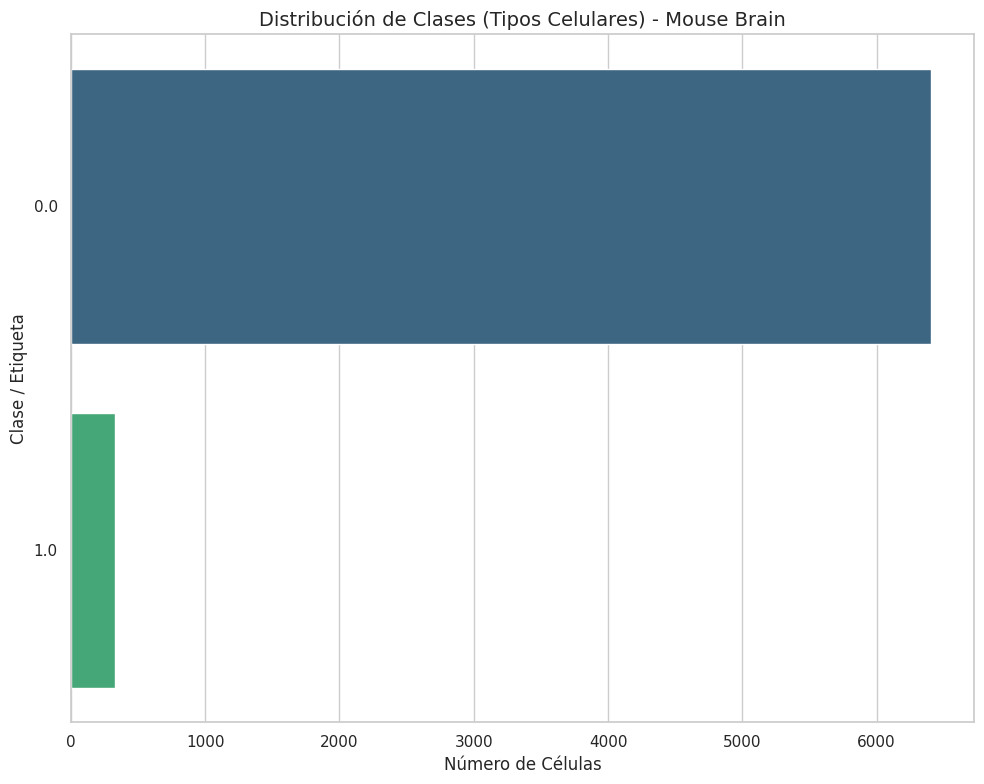

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extraemos las etiquetas de obsm
# matriz de una columna
labels = data.data.obsm['cell_type']

# Si es una matriz de NumPy, se convierte a una serie de Pandas para contar
if isinstance(labels, (pd.DataFrame, pd.Series)):
    counts = labels.iloc[:, 0].value_counts()
else:
    # Si es un array de numpy, se aplana y se cuenta
    counts = pd.Series(labels.flatten()).value_counts()

# Configuración estética
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# Gráfico de barras horizontales
sns.barplot(x=counts.values, y=counts.index.astype(str), palette='viridis')

plt.title('Distribución de Clases (Tipos Celulares) - Mouse Brain', fontsize=14)
plt.xlabel('Número de Células')
plt.ylabel('Clase / Etiqueta')
plt.tight_layout()

# Guardar
plt.savefig('distribucion_clases_mouse.pdf')
plt.show()

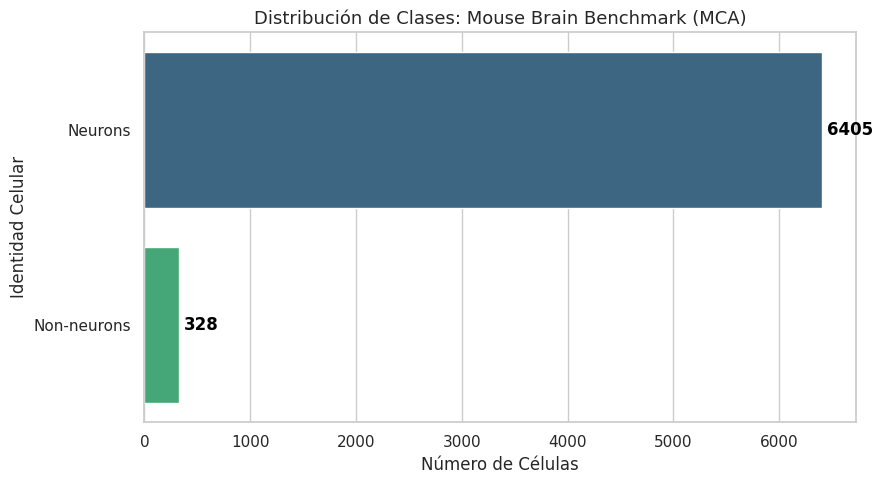

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Extracción con manejo de tipos (DataFrame o NumPy)
labels_raw = data.data.obsm['cell_type']

if isinstance(labels_raw, pd.DataFrame):
    # Si es DataFrame, tomamos la primera columna y contamos
    counts = labels_raw.iloc[:, 0].value_counts()
else:
    # Si es NumPy, aplanamos y contamos
    counts = pd.Series(np.array(labels_raw).flatten()).value_counts()

# 2. Mapeo de etiquetas
mapeo_nombres = {0.0: "Neurons", 1.0: "Non-neurons"}
counts.index = [mapeo_nombres.get(float(idx), f"Class {idx}") for idx in counts.index]

# 3. Gráfico profesional
plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x=counts.values, y=counts.index, hue=counts.index, palette="viridis", legend=False)

for i, v in enumerate(counts.values):
    ax.text(v + 50, i, f'{v}', color='black', va='center', fontweight='bold')

plt.title('Distribución de Clases: Mouse Brain Benchmark (MCA)', fontsize=13)
plt.xlabel('Número de Células')
plt.ylabel('Identidad Celular')
plt.tight_layout()
plt.savefig('distribucion_clases.pdf', bbox_inches='tight')
plt.show()

# **2. Evaluación de modelos de anotación celular**

## **2.1. Modelos evaluados**

En este experimento se evalúan distintos modelos de anotación celular implementados en el framework DANCE:

- **ACTINN**: modelo basado en redes neuronales profundas, diseñado específicamente para la clasificación de tipos celulares a partir de datos de expresión génica.

- **SVM**: clasificador basado en máquinas de vectores soporte, utilizado como baseline por su simplicidad y robustez en problemas de clasificación de alta dimensionalidad.

- **Celltypist**: método basado en modelos lineales entrenados sobre grandes atlas celulares, optimizado para tareas de anotación rápida y escalable.

- **SingleCellNet**: enfoque basado en Random Forest adaptado a datos de single-cell RNA-seq, que emplea técnicas de normalización y selección de características específicas.



## **2.2. Entrenamiento de modelos**
En la evaluación de modelos se sigue el tutorial recomendado por la herramienta DANCE específico para cada modelo.

### **ACTINN**

In [ ]:
# Initialize model and get model specific preprocessing pipeline
set_seed(0)
model = ACTINN(hidden_dims=[2000], lambd=0.005, device="cpu") # cuda NO
preprocessing_pipeline = model.preprocessing_pipeline(
    normalize=False,
    filter_genes=True
)

# Load data and perform necessary preprocessing
dataset = CellTypeAnnotationDataset(species="mouse", tissue="Brain",
                            train_dataset=[3285, 753], test_dataset=[2695], val_size=0.0)
data = dataset.load_data(transform=preprocessing_pipeline, cache=True)

# Obtain training and testing data
x_train, y_train = data.get_train_data(return_type="torch")
x_test, y_test = data.get_test_data(return_type="torch")

print(x_train)
print(y_train)

# Train and evaluate model
model.fit(
    x_train,
    y_train,
    seed=0,
    lr=0.0001,
    num_epochs=50,
    batch_size=128,
    print_cost=True
)


acc_actinn = model.score(x_test, y_test)
print(f"ACTINN ACC: {acc_actinn:.4f}")

model_actinn = model
x_test_actinn = x_test
y_test_actinn = y_test



[INFO][2026-05-14 18:29:25,225][dance][set_seed] Setting global random seed to 0
[INFO][2026-05-14 18:29:25,228][dance][_load_dfs] Loading data from ./train/mouse/mouse_Brain3285_data.csv
[INFO][2026-05-14 18:29:33,349][dance][_load_dfs] Loading data from ./train/mouse/mouse_Brain753_data.csv
[INFO][2026-05-14 18:29:35,219][dance][_load_dfs] Loading data from ./test/mouse/mouse_Brain2695_data.csv
[INFO][2026-05-14 18:29:43,648][dance][_load_dfs] Loading data from ./train/mouse/mouse_Brain3285_celltype.csv
[INFO][2026-05-14 18:29:43,657][dance][_load_dfs] Loading data from ./train/mouse/mouse_Brain753_celltype.csv
[INFO][2026-05-14 18:29:43,665][dance][_load_dfs] Loading data from ./test/mouse/mouse_Brain2695_celltype.csv
[INFO][2026-05-14 18:29:50,960][dance][_load_raw_data] Loaded expression data: AnnData object with n_obs × n_vars = 6733 × 19856
[INFO][2026-05-14 18:29:50,961][dance][_load_raw_data] Number of training samples: 4,038
[INFO][2026-05-14 18:29:50,962][dance][_load_raw_da

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [1., 0., 0.,  ..., 0., 0., 0.]])
Epoch:    0 Loss: 8.6516
Epoch:   10 Loss: 1.0926
Epoch:   20 Loss: 0.2440
Epoch:   30 Loss: 0.0948
Epoch:   40 Loss: 0.0586
ACTINN ACC: 0.8757


In [ ]:
acc_actinn = 0.8757

### **SVM**

In [ ]:
from argparse import Namespace

species = "mouse"
tissue = "Brain"
train_dataset = [753, 3285]
test_dataset = [2695]

seed = 42
dense_dim = 400

args = Namespace(
    dense_dim=dense_dim,
    gpu=-1,
    log_level="INFO",
    species=species,
    tissue=tissue,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    seed=seed,
    num_runs=1,
    val_size=0.0,
    cache=False
)
set_seed(seed)

# Initialize model and get model specific preprocessing pipeline
model = SVM(args, random_state=seed)

preprocessing_pipeline = model.preprocessing_pipeline(
    n_components=dense_dim,
    log_level="INFO"
)

dataset = CellTypeAnnotationDataset(
    species=species,
    tissue=tissue,
    train_dataset=train_dataset,
    test_dataset=test_dataset
)

data = dataset.load_data(
    transform=preprocessing_pipeline,
    cache=False
)

x_train, y_train = data.get_train_data()
x_test, y_test = data.get_test_data()

y_train_converted = y_train.argmax(1)

print("Train:", x_train.shape, y_train.shape)
print("Test:", x_test.shape, y_test.shape)

model.fit(x_train, y_train_converted)



acc_svm = model.score(x_test, y_test)
print(f"SVM ACC: {acc_svm:.4f}")

# Guardado para evaluación
model_svm = model
x_test_svm = x_test
y_test_svm = y_test

[INFO][2026-05-14 19:04:40,105][dance][set_seed] Setting global random seed to 42
[INFO][2026-05-14 19:04:40,125][dance][_load_dfs] Loading data from ./train/mouse/mouse_Brain753_data.csv
[INFO][2026-05-14 19:04:43,100][dance][_load_dfs] Loading data from ./train/mouse/mouse_Brain3285_data.csv
[INFO][2026-05-14 19:04:54,624][dance][_load_dfs] Loading data from ./test/mouse/mouse_Brain2695_data.csv
[INFO][2026-05-14 19:05:03,402][dance][_load_dfs] Loading data from ./train/mouse/mouse_Brain753_celltype.csv
[INFO][2026-05-14 19:05:03,409][dance][_load_dfs] Loading data from ./train/mouse/mouse_Brain3285_celltype.csv
[INFO][2026-05-14 19:05:03,419][dance][_load_dfs] Loading data from ./test/mouse/mouse_Brain2695_celltype.csv
[INFO][2026-05-14 19:05:12,915][dance][_load_raw_data] Loaded expression data: AnnData object with n_obs × n_vars = 6733 × 19856
[INFO][2026-05-14 19:05:12,916][dance][_load_raw_data] Number of training samples: 3,230
[INFO][2026-05-14 19:05:12,917][dance][_load_raw_d

Train: (3230, 400) (3230, 11)
Test: (2695, 400) (2695, 11)
SVM ACC: 0.7065


In [ ]:
acc_svm = 0.7065

### **Celltypist**

In [ ]:
from dance.utils import set_seed
from dance.datasets.singlemodality import CellTypeAnnotationDataset
from dance.modules.single_modality.cell_type_annotation.celltypist import Celltypist

# Reproducibilidad
set_seed(42)

# Modelo
model = Celltypist(majority_voting=True)  # puedes probar True/False

# Pipeline del modelo
preprocessing_pipeline = model.preprocessing_pipeline()

# Dataset (Mouse Brain)
dataset = CellTypeAnnotationDataset(
    species="mouse",
    tissue="Brain",
    train_dataset=[753, 3285],
    test_dataset=[2695],
    val_size=0.0
)

# Carga y transformación
data = dataset.load_data(
    transform=preprocessing_pipeline,
    cache=False
)

# Datos
x_train, y_train = data.get_train_data()
x_test, y_test = data.get_test_data()

# convertir etiquetas
y_train = y_train.argmax(1)

print("Train:", x_train.shape, y_train.shape)
print("Test:", x_test.shape, y_test.shape)

# Entrenamiento
model.fit(
    x_train,
    y_train,
    n_jobs=10,
    max_iter=200,
    use_SGD=True
)

# Evaluación
acc_celltypist = model.score(x_test, y_test)
print(f"Celltypist ACC: {acc_celltypist:.4f}")


# Guardado para evaluación
model_celltypist = model
x_test_celltypist = x_test
y_test_celltypist = y_test

[INFO][2026-05-14 19:05:32,294][dance][set_seed] Setting global random seed to 42
[INFO][2026-05-14 19:05:32,298][dance][_load_dfs] Loading data from ./train/mouse/mouse_Brain753_data.csv
[INFO][2026-05-14 19:05:33,426][dance][_load_dfs] Loading data from ./train/mouse/mouse_Brain3285_data.csv
[INFO][2026-05-14 19:05:42,736][dance][_load_dfs] Loading data from ./test/mouse/mouse_Brain2695_data.csv
[INFO][2026-05-14 19:05:50,700][dance][_load_dfs] Loading data from ./train/mouse/mouse_Brain753_celltype.csv
[INFO][2026-05-14 19:05:50,707][dance][_load_dfs] Loading data from ./train/mouse/mouse_Brain3285_celltype.csv
[INFO][2026-05-14 19:05:50,721][dance][_load_dfs] Loading data from ./test/mouse/mouse_Brain2695_celltype.csv
[INFO][2026-05-14 19:05:55,067][dance][_load_raw_data] Loaded expression data: AnnData object with n_obs × n_vars = 6733 × 19856
[INFO][2026-05-14 19:05:55,068][dance][_load_raw_data] Number of training samples: 4,038
[INFO][2026-05-14 19:05:55,070][dance][_load_raw_d

Train: (4038, 19856) (4038,)
Test: (2695, 19856) (2695, 11)


[INFO][2026-05-14 19:05:58,341][dance][SGDClassifier_celltypist] Training data using SGD logistic regression
[INFO][2026-05-14 19:05:58,342][dance][SGDClassifier_celltypist] SGDlassifier training start...
[INFO][2026-05-14 19:06:09,818][dance][fit] Model training done
[INFO][2026-05-14 19:06:09,834][dance][__init__] Input data has 2,695 cells and 19,856 genes
[INFO][2026-05-14 19:06:09,835][dance][celltype] Matching reference genes in the model
[INFO][2026-05-14 19:06:20,722][dance][celltype] 19,856 features used for prediction
[INFO][2026-05-14 19:07:04,302][dance][celltype] Scaling input data
[INFO][2026-05-14 19:07:06,005][dance][celltype] Predicting labels
[INFO][2026-05-14 19:07:06,262][dance][celltype] Prediction done
[INFO][2026-05-14 19:07:06,265][dance][over_cluster] Can not detect a neighborhood graph, will construct one before the over-clustering
[INFO][2026-05-14 19:07:52,855][dance][over_cluster] Over-clustering input data with resolution set to 5
[INFO][2026-05-14 19:07:5

Celltypist ACC: 0.8831


In [ ]:
acc_celltypist = 0.8831

### **SingleCellNet**

In [ ]:
# Reproducibilidad
set_seed(10)

# Modelo
model = SingleCellNet(num_trees=1000)

# Pipeline específico de SingleCellNet
preprocessing_pipeline = model.preprocessing_pipeline(
    normalize=False,          # igual que tutorial: desactivado por defecto
    num_top_genes=10,
    num_top_gene_pairs=25
)

# Dataset Mouse Brain
dataset = CellTypeAnnotationDataset(
    species="mouse",
    tissue="Brain",
    train_dataset=[753],
    test_dataset=[2695],
    val_size=0.0
)

# Carga y preprocesamiento
data = dataset.load_data(
    transform=preprocessing_pipeline,
    cache=False
)

# Datos
x_train, y_train = data.get_train_data(return_type="numpy")
x_test, y_test = data.get_test_data(return_type="numpy")

# Convertir y_train de one-hot a índices
y_train = y_train.argmax(1)

# Añadir columna "unsure" al test
y_test = np.hstack([
    y_test,
    np.zeros((y_test.shape[0], 1))
])

print("Train:", x_train.shape, y_train.shape)
print("Test:", x_test.shape, y_test.shape)

# Entrenamiento
model.fit(
    x_train,
    y_train,
    stratify=True,
    num_rand=100,
    random_state=10
)

# Evaluación
acc_scn = model.score(x_test, y_test)
print(f"SingleCellNet ACC: {acc_scn:.4f}")


# Guardado para evaluación
model_scn = model
x_test_scn = x_test
y_test_scn = y_test

[INFO][2026-05-14 19:07:53,765][dance][set_seed] Setting global random seed to 10
[INFO][2026-05-14 19:07:53,769][dance][_load_dfs] Loading data from ./train/mouse/mouse_Brain753_data.csv
[INFO][2026-05-14 19:07:54,862][dance][_load_dfs] Loading data from ./test/mouse/mouse_Brain2695_data.csv
[INFO][2026-05-14 19:08:02,242][dance][_load_dfs] Loading data from ./train/mouse/mouse_Brain753_celltype.csv
[INFO][2026-05-14 19:08:02,251][dance][_load_dfs] Loading data from ./test/mouse/mouse_Brain2695_celltype.csv
[INFO][2026-05-14 19:08:03,893][dance][_load_raw_data] Loaded expression data: AnnData object with n_obs × n_vars = 3448 × 17378
[INFO][2026-05-14 19:08:03,895][dance][_load_raw_data] Number of training samples: 753
[INFO][2026-05-14 19:08:03,896][dance][_load_raw_data] Number of testing samples: 2,695
[INFO][2026-05-14 19:08:03,897][dance][_load_raw_data] Cell-types (n=10):
['Astrocyte',
 'Astroglial cell',
 'Granulocyte',
 'Macrophage',
 'Microglia',
 'Myelinating oligodendrocyte

Train: (753, 249) (753,)
Test: (2695, 249) (2695, 11)
SingleCellNet ACC: 0.8631


In [ ]:
acc_scn = 0.8631


## **2.3. Tabla de resultados**

En particular, se han utilizado las siguientes métricas:

- **Accuracy**: proporción de predicciones correctas sobre el total de muestras.
- **Balanced Accuracy**: promedio del recall obtenido en cada clase, proporcionando una evaluación más robusta en escenarios con desbalanceo entre clases.
- **F1-score macro**: promedio no ponderado del F1-score calculado independientemente para cada clase, otorgando la misma relevancia a todas las categorías.
- **ARI (Adjusted Rand Index)**: mide la concordancia entre las etiquetas reales y las predichas, corrigiendo el efecto del azar.



In [ ]:
#TABLA RESULTADOS ACCURACY
import pandas as pd

tabla_acc = pd.DataFrame({
    "Modelo": ["SVM", "Celltypist", "ACTINN", "SingleCellNet"],
    "Accuracy": [acc_svm, acc_celltypist, acc_actinn, acc_scn]
})

tabla_acc = tabla_acc.sort_values(by="Accuracy", ascending=False)

tabla_acc

In [ ]:
# ============================================================
# Evaluación de los modelos
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    adjusted_rand_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# Funciones auxiliares
# ------------------------------------------------------------

def to_numpy(x):
    """Convierte tensores/listas/matrices a numpy."""
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def to_label_vector(y):
    """Convierte etiquetas one-hot o probabilidades a vector de clases."""
    y = to_numpy(y)

    if y.ndim > 1:
        y = np.argmax(y, axis=1)

    return y.astype(int)


def get_predictions(model, x_test):
    """
    Obtiene predicciones del modelo de forma robusta.
    Primero intenta predict().
    Si devuelve probabilidades/logits, se convierten a clases.
    """
    y_pred = model.predict(x_test)
    y_pred = to_numpy(y_pred)

    if y_pred.ndim > 1:
        y_pred = np.argmax(y_pred, axis=1)

    return y_pred.astype(int)


# ------------------------------------------------------------
# Modelos
# ------------------------------------------------------------

modelos_evaluacion = {
    "ACTINN": {
        "model": model_actinn,
        "x_test": x_test_actinn,
        "y_test": y_test_actinn,
        "accuracy_reportada": acc_actinn,
        "familia": "Deep Learning",
        "tipo": "Red neuronal multicapa"
    },
    "SVM": {
        "model": model_svm,
        "x_test": x_test_svm,
        "y_test": y_test_svm,
        "accuracy_reportada": acc_svm,
        "familia": "Machine Learning",
        "tipo": "Support Vector Machine con PCA"
    },
    "Celltypist": {
        "model": model_celltypist,
        "x_test": x_test_celltypist,
        "y_test": y_test_celltypist,
        "accuracy_reportada": acc_celltypist,
        "familia": "Machine Learning",
        "tipo": "Clasificador lineal optimizado para scRNA-seq"
    },
    "SingleCellNet": {
        "model": model_scn,
        "x_test": x_test_scn,
        "y_test": y_test_scn,
        "accuracy_reportada": acc_scn,
        "familia": "Machine Learning",
        "tipo": "Random Forest sobre pares de genes"
    }
}

# ------------------------------------------------------------
# Generación de predicciones
# ------------------------------------------------------------

predicciones_modelos = {}
filas_metricas = []
classification_reports = {}
confusion_matrices = {}

for nombre, info in modelos_evaluacion.items():

    print(f"\nProcesando modelo: {nombre}")

    try:
        y_true = to_label_vector(info["y_test"])
        y_pred = get_predictions(info["model"], info["x_test"])

        # Ajuste de seguridad por si alguna salida tiene longitud distinta
        n = min(len(y_true), len(y_pred))
        y_true = y_true[:n]
        y_pred = y_pred[:n]

        predicciones_modelos[nombre] = (y_true, y_pred)

        acc_calc = accuracy_score(y_true, y_pred)

        filas_metricas.append({
            "modelo": nombre,
            "familia": info["familia"],
            "tipo": info["tipo"],
            "accuracy_reportada": info["accuracy_reportada"],
            "accuracy_calculada": acc_calc,
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
            "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
            "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
            "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
            "ari": adjusted_rand_score(y_true, y_pred),
            "n_celulas_test": len(y_true)
        })

        classification_reports[nombre] = classification_report(
            y_true,
            y_pred,
            zero_division=0,
            output_dict=True
        )

        confusion_matrices[nombre] = confusion_matrix(y_true, y_pred)

        print(f"Predicciones generadas correctamente para {nombre}")
        print(f"Accuracy recalculada: {acc_calc:.4f}")

    except Exception as e:
        print(f"No se pudieron generar predicciones para {nombre}: {e}")

# ------------------------------------------------------------
# Tabla final de métricas
# ------------------------------------------------------------

df_metricas = pd.DataFrame(filas_metricas)

if len(df_metricas) > 0:
    df_metricas["error_rate"] = 1 - df_metricas["accuracy_calculada"]

    df_metricas = df_metricas.sort_values(
        by=["f1_macro", "accuracy_calculada"],
        ascending=False
    ).reset_index(drop=True)

    df_metricas["ranking"] = np.arange(1, len(df_metricas) + 1)

    best_f1 = df_metricas["f1_macro"].max()
    df_metricas["gap_f1_best"] = best_f1 - df_metricas["f1_macro"]

    columnas = [
        "ranking",
        "modelo",
        "familia",
        "tipo",
        "accuracy_reportada",
        "accuracy_calculada",
        "balanced_accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "precision_weighted",
        "recall_weighted",
        "f1_weighted",
        "ari",
        "error_rate",
        "gap_f1_best",
        "n_celulas_test"
    ]

    df_metricas = df_metricas[columnas]

    print("\nTabla final de métricas avanzadas:")
    display(df_metricas)

else:
    print("No se pudo calcular ninguna métrica avanzada.")

## **2.4. Visualización**

In [ ]:
# Visualización de resultados


import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import ConfusionMatrixDisplay

output_dir = Path("figuras_resultados_modelos")
output_dir.mkdir(exist_ok=True)


# Tabla resumen para memoria
tabla_memoria = df_metricas.copy()

for col in [
    "accuracy_reportada",
    "accuracy_calculada",
    "balanced_accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "precision_weighted",
    "recall_weighted",
    "f1_weighted",
    "ari",
    "error_rate",
    "gap_f1_best"
]:
    tabla_memoria[col] = tabla_memoria[col].round(4)

print("Tabla resumen para incluir en la memoria:")
display(tabla_memoria)

tabla_memoria.to_csv(output_dir / "tabla_metricas_modelos.csv", index=False)

# ------------------------------------------------------------
# Figura 1: Accuracy calculada

plt.figure(figsize=(9, 5))

bars = plt.bar(
    df_metricas["modelo"],
    df_metricas["accuracy_calculada"] * 100
)

plt.title("Accuracy de los modelos evaluados")
plt.xlabel("Modelo")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

for bar, value in zip(bars, df_metricas["accuracy_calculada"] * 100):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(output_dir / "accuracy_modelos.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# Figura 2: F1-score macro

plt.figure(figsize=(9, 5))

bars = plt.bar(
    df_metricas["modelo"],
    df_metricas["f1_macro"] * 100
)

plt.title("F1-score macro de los modelos evaluados")
plt.xlabel("Modelo")
plt.ylabel("F1-score macro (%)")
plt.ylim(0, 100)

for bar, value in zip(bars, df_metricas["f1_macro"] * 100):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(output_dir / "f1_macro_modelos.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# Figura 3: Balanced accuracy

plt.figure(figsize=(9, 5))

bars = plt.bar(
    df_metricas["modelo"],
    df_metricas["balanced_accuracy"] * 100
)

plt.title("Balanced accuracy de los modelos evaluados")
plt.xlabel("Modelo")
plt.ylabel("Balanced accuracy (%)")
plt.ylim(0, 100)

for bar, value in zip(bars, df_metricas["balanced_accuracy"] * 100):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(output_dir / "balanced_accuracy_modelos.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# Figura 4: ARI

plt.figure(figsize=(9, 5))

bars = plt.bar(
    df_metricas["modelo"],
    df_metricas["ari"]
)

plt.title("Adjusted Rand Index de los modelos evaluados")
plt.xlabel("Modelo")
plt.ylabel("ARI")

for bar, value in zip(bars, df_metricas["ari"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(output_dir / "ari_modelos.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# Figura 5: Comparación conjunta de métricas

metricas_plot = df_metricas.set_index("modelo")[
    [
        "accuracy_calculada",
        "balanced_accuracy",
        "f1_macro",
        "f1_weighted",
        "ari"
    ]
]

ax = metricas_plot.plot(kind="bar", figsize=(11, 6))

plt.title("Comparación conjunta de métricas por modelo")
plt.xlabel("Modelo")
plt.ylabel("Valor de la métrica")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.legend(
    [
        "Accuracy",
        "Balanced accuracy",
        "F1 macro",
        "F1 weighted",
        "ARI"
    ],
    loc="lower right"
)

plt.tight_layout()
plt.savefig(output_dir / "comparacion_metricas_modelos.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# Figura 6: Matrices de confusión

for nombre, (y_true, y_pred) in predicciones_modelos.items():

    plt.figure(figsize=(7, 6))

    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        cmap="Blues",
        xticks_rotation=45,
        colorbar=True
    )

    plt.title(f"Matriz de confusión - {nombre}")
    plt.tight_layout()
    plt.savefig(output_dir / f"matriz_confusion_{nombre}.png", dpi=300)
    plt.show()


#Matrices de confusión combinadas (2x2)

# Modelos en orden (ajústalo si quieres otro orden)
modelos_orden = ["ACTINN", "Celltypist", "SingleCellNet", "SVM"]

# Crear figura
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, modelo in enumerate(modelos_orden):

    if modelo not in predicciones_modelos:
        axes[i].set_title(f"{modelo} (no disponible)")
        axes[i].axis("off")
        continue

    y_true, y_pred = predicciones_modelos[modelo]

    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(
        ax=axes[i],
        colorbar=False,      # evita 4 barras de color
        xticks_rotation=45
    )

    axes[i].set_title(modelo)

# Ajuste general
plt.suptitle("Matrices de confusión de los modelos evaluados", fontsize=16)
plt.tight_layout()

# Guardar
plt.savefig("figuras_resultados_modelos/matrices_confusion_combined.png", dpi=300)

plt.show()

# ------------------------------------------------------------
# Figura 7: Diagrama metodológico del experimento

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.axis("off")

pasos = [
    "Benchmark\nMouse Brain",
    "Pipeline específico\npor modelo",
    "Entrenamiento\nsupervisado",
    "Predicción sobre\nconjunto test",
    "Evaluación\nmultimétrica"
]

x_positions = np.linspace(0.08, 0.92, len(pasos))
y = 0.5

for i, (x, texto) in enumerate(zip(x_positions, pasos)):
    ax.text(
        x,
        y,
        texto,
        ha="center",
        va="center",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black")
    )

    if i < len(pasos) - 1:
        ax.annotate(
            "",
            xy=(x_positions[i + 1] - 0.07, y),
            xytext=(x + 0.07, y),
            arrowprops=dict(arrowstyle="->", lw=1.5)
        )

plt.title(
    "Pipeline experimental para la evaluación de modelos de anotación celular",
    fontsize=13
)

plt.tight_layout()
plt.savefig(output_dir / "pipeline_evaluacion_modelos.png", dpi=300)
plt.show()


# ------------------------------------------------------------
# Figura 8: PCA del conjunto test coloreado por acierto/error

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Seleccionar el mejor modelo según F1 macro
mejor_modelo_nombre = df_metricas.iloc[0]["modelo"]

x_test_mejor = modelos_evaluacion[mejor_modelo_nombre]["x_test"]
y_true_mejor, y_pred_mejor = predicciones_modelos[mejor_modelo_nombre]

# Convertir x_test a numpy
x_test_np = to_numpy(x_test_mejor)

# Si viene en formato sparse, convertir a dense
if hasattr(x_test_np, "toarray"):
    x_test_np = x_test_np.toarray()

# Escalado previo al PCA
x_test_scaled = StandardScaler().fit_transform(x_test_np)

# PCA a dos componentes
pca = PCA(n_components=2, random_state=42)
x_pca = pca.fit_transform(x_test_scaled)

aciertos = y_true_mejor == y_pred_mejor

plt.figure(figsize=(8, 6))

plt.scatter(
    x_pca[aciertos, 0],
    x_pca[aciertos, 1],
    s=12,
    alpha=0.7,
    label="Correctamente clasificadas"
)

plt.scatter(
    x_pca[~aciertos, 0],
    x_pca[~aciertos, 1],
    s=18,
    alpha=0.9,
    label="Incorrectamente clasificadas",
    marker="x"
)

plt.title(f"PCA del conjunto test según acierto/error - {mejor_modelo_nombre}")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% var.)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% var.)")
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / f"pca_acierto_error_{mejor_modelo_nombre}.png", dpi=300)
plt.show()

print(
    f"PCA generado para el modelo {mejor_modelo_nombre}. "
    f"Varianza explicada acumulada por PC1 y PC2: "
    f"{pca.explained_variance_ratio_.sum()*100:.2f}%."
)


# ------------------------------------------------------------
# Figura 9: PCA del conjunto test coloreado por clase real

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    x_pca[:, 0],
    x_pca[:, 1],
    c=y_true_mejor,
    s=12,
    alpha=0.8
)

plt.title(f"PCA del conjunto test coloreado por clase real - {mejor_modelo_nombre}")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% var.)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% var.)")
plt.colorbar(scatter, label="Clase real")
plt.tight_layout()
plt.savefig(output_dir / f"pca_clase_real_{mejor_modelo_nombre}.png", dpi=300)
plt.show()



# ------------------------------------------------------------
# Interpretación automática

mejor = df_metricas.iloc[0]
peor = df_metricas.iloc[-1]

print("\nInterpretación de resultados:")
print(
    f"El modelo con mejor comportamiento global según F1-score macro es "
    f"{mejor['modelo']}, con un F1 macro de {mejor['f1_macro']:.4f} "
    f"y una accuracy de {mejor['accuracy_calculada']:.4f}."
)

print(
    f"El modelo con menor rendimiento relativo es {peor['modelo']}, "
    f"con un F1 macro de {peor['f1_macro']:.4f} "
    f"y una accuracy de {peor['accuracy_calculada']:.4f}."
)

print(
    "\nEl F1-score macro resulta especialmente relevante en este experimento, "
    "ya que el conjunto de datos presenta un claro desbalance entre tipos celulares. "
    "Por ello, esta métrica permite valorar de forma más equilibrada el rendimiento "
    "sobre clases mayoritarias y minoritarias."
)

print(f"\nFiguras y tablas guardadas en: {output_dir.resolve()}")

NameError: name 'df_metricas' is not defined